# MNIST: multilayer perceptrons with PyTorch

Multilayer perceptrons (MLPs) can be used for both regression and classification. In this notebook we train a classic MLP to recognize handwritten digits from the MNIST dataset, compare it with a model that uses dropout, and investigate the resulting classifiers.

This notebook follows the same learning path as the Keras version while using PyTorch's `Dataset`, `DataLoader`, explicit training loop, and checkpoint conventions.

## Learning objectives

After working through this notebook, you should be able to:

- prepare a built-in vision dataset with transformations and data loaders;
- explain why a classification model returns logits rather than probabilities during training;
- implement and train an MLP with and without dropout;
- use validation evidence to select a model without consulting the test set;
- interpret a confusion matrix and investigate sensitivity to initialization.


## Configuration

The complete experiment mirrors the 100-epoch Keras notebook, including ten repeated training runs. That is computationally expensive. The default quick configuration preserves the workflow with shorter runs; set `FULL_EXPERIMENT = True` for the complete experiment.


In [31]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import MNIST
from torchvision.transforms import v2


In [32]:
FULL_EXPERIMENT = False

BATCH_SIZE = 128
EPOCHS = 100 if FULL_EXPERIMENT else 5
SENSITIVITY_RUNS = 10 if FULL_EXPERIMENT else 3
SENSITIVITY_EPOCHS = 100 if FULL_EXPERIMENT else 5

SPLIT_SEED = 1234
MODEL_SEED = 4958
DATA_ORDER_SEED = 2718

DATA_DIR = Path.cwd() / "data"
MODEL_DIR = Path.cwd() / "models"


## Reproducibility and device selection

PyTorch uses its own random-number generator. A fixed seed makes the CPU run reproducible under the same software and hardware configuration. Exact results can still differ across devices or PyTorch versions because some accelerator operations are nondeterministic or use different numerical implementations.


In [33]:
def seed_everything(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(MODEL_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## Data preparation

### Obtaining and transforming the dataset

MNIST is provided by `torchvision.datasets`. Unlike Keras' `load_data()`, which returns complete arrays, a PyTorch `Dataset` retrieves individual image-label pairs. A `DataLoader` will later handle batching and shuffling.

The transformation converts each image to a `float32` tensor and scales its pixel values from the integer range 0–255 to the floating-point range 0–1. Flattening is part of the model, so the dataset retains the meaningful image shape `[channel, height, width]`.


In [34]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])


In [35]:
full_train_dataset = MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform,
)

test_dataset = MNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform,
)


### Validation set

We split the 60,000 original training examples into 45,000 training and 15,000 validation examples. The test set remains untouched while models and training choices are being compared.


In [36]:
split_generator = torch.Generator().manual_seed(SPLIT_SEED)

train_dataset, validation_dataset = random_split(
    full_train_dataset,
    [45_000, 15_000],
    generator=split_generator,
)

len(train_dataset), len(validation_dataset), len(test_dataset)


(45000, 15000, 10000)

### Data loaders

The training loader shuffles examples at every epoch. Supplying its generator explicitly lets us reproduce the same sequence of shuffles when comparing models. Validation and test loaders do not shuffle because example order does not affect their metrics.


In [37]:
pin_memory = device.type == "cuda"


def make_train_loader(seed=DATA_ORDER_SEED):
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
        num_workers=0,
        pin_memory=pin_memory,
    )


validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=pin_memory,
)


### Verification

Before training, inspect an image, its tensor properties, and its integer class label.


shape: (1, 28, 28)
dtype: torch.float32
value range: [0.0, 1.0]
label: 7


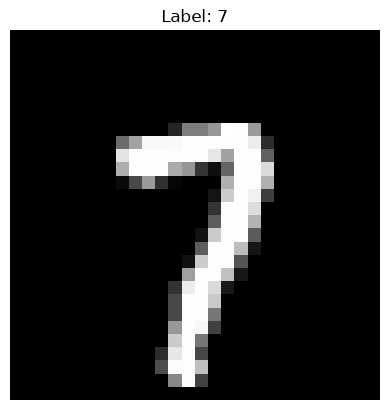

In [38]:
image, label = train_dataset[0]

print(f"shape: {tuple(image.shape)}")
print(f"dtype: {image.dtype}")
print(f"value range: [{image.min().item():.1f}, {image.max().item():.1f}]")
print(f"label: {label}")

plt.imshow(image.squeeze(0), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()


The target is an integer class index rather than a one-hot vector. This is exactly what `nn.CrossEntropyLoss` expects.

## Classic multilayer perceptron

The network has 784 inputs (28 × 28 pixels), two hidden layers with 512 units and ReLU activations, and 10 output values—one per digit. `nn.Flatten` converts each image to 784 features inside the model.

The final layer returns **logits**, not Softmax probabilities. `nn.CrossEntropyLoss` combines the numerically stable LogSoftmax and negative log-likelihood operations internally.


In [39]:
def make_mlp(dropout_probability=0.0):
    layers = [
        nn.Flatten(),
        nn.Linear(28 * 28, 512),
        nn.ReLU(),
    ]

    if dropout_probability > 0.0:
        layers.append(nn.Dropout(dropout_probability))

    layers.extend([
        nn.Linear(512, 512),
        nn.ReLU(),
    ])

    if dropout_probability > 0.0:
        layers.append(nn.Dropout(dropout_probability))

    layers.append(nn.Linear(512, 10))
    return nn.Sequential(*layers)


In [40]:
seed_everything(MODEL_SEED)
model = make_mlp().to(device)

model


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=512, bias=True)
  (4): ReLU()
  (5): Linear(in_features=512, out_features=10, bias=True)
)

In [41]:
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(f"Trainable parameters: {parameter_count:,}")


Trainable parameters: 669,706


### Loss function and optimizer

The loss measures multiclass classification error, while stochastic gradient descent updates the weights. The learning rate of 0.01 matches the default used by the Keras SGD optimizer in the original notebook.


In [42]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)


### Training and evaluation functions

Keras hides the training loop behind `model.fit`. PyTorch makes its steps explicit:

1. switch the model to training mode;
2. compute logits and loss for a batch;
3. compute gradients with backpropagation;
4. update parameters with the optimizer;
5. aggregate loss and accuracy over the epoch.

Evaluation switches to evaluation mode—important for dropout—and disables gradient tracking.


In [43]:
def train_one_epoch(model, data_loader, loss_function, optimizer):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for features, targets in data_loader:
        features = features.to(device, non_blocking=pin_memory)
        targets = targets.to(device, non_blocking=pin_memory)

        optimizer.zero_grad(set_to_none=True)
        logits = model(features)
        loss = loss_function(logits, targets)
        loss.backward()
        optimizer.step()

        batch_size = targets.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == targets).sum().item()
        total_examples += batch_size

    return {
        "loss": total_loss / total_examples,
        "accuracy": total_correct / total_examples,
    }


In [44]:
@torch.inference_mode()
def evaluate(model, data_loader, loss_function):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for features, targets in data_loader:
        features = features.to(device, non_blocking=pin_memory)
        targets = targets.to(device, non_blocking=pin_memory)

        logits = model(features)
        loss = loss_function(logits, targets)

        batch_size = targets.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == targets).sum().item()
        total_examples += batch_size

    return {
        "loss": total_loss / total_examples,
        "accuracy": total_correct / total_examples,
    }


In [45]:
def fit(
    model,
    train_loader,
    validation_loader,
    loss_function,
    optimizer,
    epochs,
    verbose=True,
):
    history = {
        "loss": [],
        "accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }

    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(
            model, train_loader, loss_function, optimizer
        )
        validation_metrics = evaluate(
            model, validation_loader, loss_function
        )

        history["loss"].append(train_metrics["loss"])
        history["accuracy"].append(train_metrics["accuracy"])
        history["val_loss"].append(validation_metrics["loss"])
        history["val_accuracy"].append(validation_metrics["accuracy"])

        if verbose:
            print(
                f"Epoch {epoch:3d}/{epochs}: "
                f"loss={train_metrics['loss']:.4f}, "
                f"accuracy={train_metrics['accuracy']:.4f}, "
                f"val_loss={validation_metrics['loss']:.4f}, "
                f"val_accuracy={validation_metrics['accuracy']:.4f}"
            )

    return history


### Training


In [46]:
train_loader = make_train_loader()

model_history = fit(
    model=model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    epochs=EPOCHS,
)


Epoch   1/5: loss=2.1722, accuracy=0.4424, val_loss=1.9289, val_accuracy=0.6621
Epoch   2/5: loss=1.3893, accuracy=0.7416, val_loss=0.9133, val_accuracy=0.7975
Epoch   3/5: loss=0.7137, accuracy=0.8292, val_loss=0.5937, val_accuracy=0.8432
Epoch   4/5: loss=0.5221, accuracy=0.8638, val_loss=0.4826, val_accuracy=0.8691
Epoch   5/5: loss=0.4422, accuracy=0.8800, val_loss=0.4279, val_accuracy=0.8818


Plot the history of the training process. Comparing training and validation curves helps diagnose underfitting and overfitting.


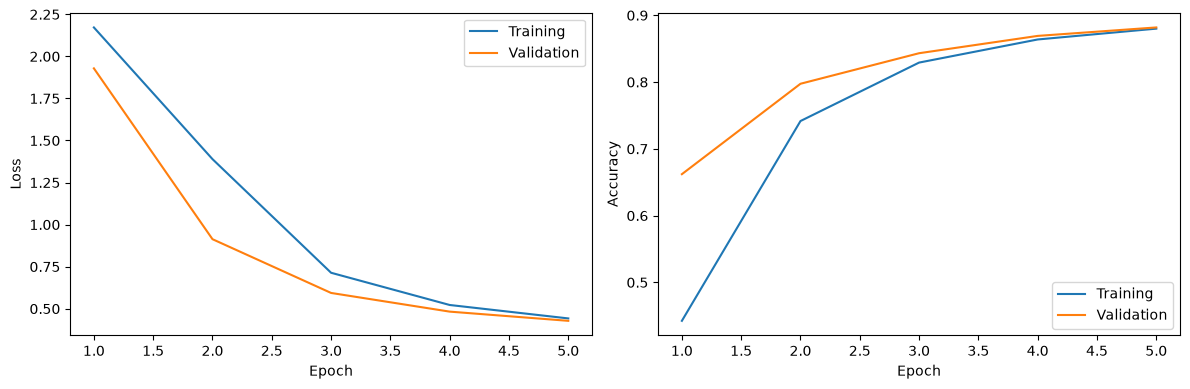

In [47]:
def plot_history(history):
    epochs = np.arange(1, len(history["loss"]) + 1)

    figure, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["loss"], label="Training")
    axes[0].plot(epochs, history["val_loss"], label="Validation")
    axes[0].set(xlabel="Epoch", ylabel="Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["accuracy"], label="Training")
    axes[1].plot(epochs, history["val_accuracy"], label="Validation")
    axes[1].set(xlabel="Epoch", ylabel="Accuracy")
    axes[1].legend(loc="lower right")

    figure.tight_layout()


plot_history(model_history)


Compare performance on the training and validation sets. These are the development results used to diagnose and select models. The test set remains untouched until every model choice has been frozen.


In [48]:
def evaluate_development_sets(model):
    loaders = {
        "train": DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=0,
            pin_memory=pin_memory,
        ),
        "validation": validation_loader,
    }

    results = {}
    for name, data_loader in loaders.items():
        results[name] = evaluate(model, data_loader, loss_function)
        metrics = results[name]
        print(
            f"{name:10s}: loss={metrics['loss']:.4f}, "
            f"accuracy={metrics['accuracy']:.4f}"
        )

    return results


model_development_results = evaluate_development_sets(model)


train     : loss=0.4151, accuracy=0.8864
validation: loss=0.4279, accuracy=0.8818


### Save and reload the model

Saving a `state_dict` stores learned parameters without serializing arbitrary Python objects. To reload it, recreate the architecture and then load the weights.


In [49]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODEL_DIR / "mnist_mlp.pt"

torch.save(model.state_dict(), model_path)
print(f"Saved weights to {model_path}")


Saved weights to /home/gjb/Projects/Machine-learning-with-Python/source-code/pytorch/models/mnist_mlp.pt


In [50]:
reloaded_model = make_mlp().to(device)
reloaded_model.load_state_dict(
    torch.load(model_path, map_location=device, weights_only=True)
)

reloaded_validation_metrics = evaluate(
    reloaded_model, validation_loader, loss_function
)
reloaded_validation_metrics


{'loss': 0.42791415793100995, 'accuracy': 0.8818}

## Dropout layers

Dropout randomly sets some activations to zero during training, discouraging the network from relying too strongly on particular paths. It is disabled automatically in evaluation mode.

Before running the cell, predict how dropout will affect:

- training loss and accuracy;
- the gap between training and validation performance;
- test performance.

We reset both the model seed and data-loader seed so that the comparison changes the architecture while keeping initialization and batch order as comparable as possible.


In [51]:
seed_everything(MODEL_SEED)
dropout_model = make_mlp(dropout_probability=0.2).to(device)
dropout_optimizer = torch.optim.SGD(dropout_model.parameters(), lr=0.01)
dropout_train_loader = make_train_loader(DATA_ORDER_SEED)

dropout_model


Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=512, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=512, out_features=512, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.2, inplace=False)
  (7): Linear(in_features=512, out_features=10, bias=True)
)

In [52]:
dropout_model_history = fit(
    model=dropout_model,
    train_loader=dropout_train_loader,
    validation_loader=validation_loader,
    loss_function=loss_function,
    optimizer=dropout_optimizer,
    epochs=EPOCHS,
)


Epoch   1/5: loss=2.1879, accuracy=0.3948, val_loss=1.9631, val_accuracy=0.6483
Epoch   2/5: loss=1.4723, accuracy=0.7013, val_loss=0.9565, val_accuracy=0.7885
Epoch   3/5: loss=0.7854, accuracy=0.7976, val_loss=0.6125, val_accuracy=0.8391
Epoch   4/5: loss=0.5830, accuracy=0.8378, val_loss=0.4949, val_accuracy=0.8659
Epoch   5/5: loss=0.4965, accuracy=0.8589, val_loss=0.4372, val_accuracy=0.8804


train     : loss=0.4247, accuracy=0.8847
validation: loss=0.4372, accuracy=0.8804


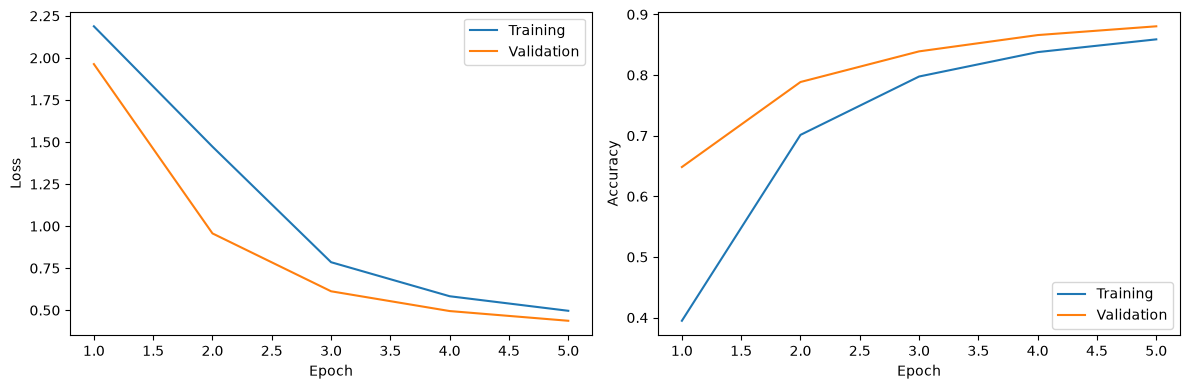

In [53]:
plot_history(dropout_model_history)
dropout_model_development_results = evaluate_development_sets(
    dropout_model
)


In [54]:
dropout_model_path = MODEL_DIR / "mnist_mlp_dropout.pt"
torch.save(dropout_model.state_dict(), dropout_model_path)
print(f"Saved weights to {dropout_model_path}")


Saved weights to /home/gjb/Projects/Machine-learning-with-Python/source-code/pytorch/models/mnist_mlp_dropout.pt


## Understanding and selecting the model

The selection rule must be declared before consulting the test set. Here we select the candidate with the lowest validation loss. Accuracy remains useful to report, but loss uses the full predicted distribution and is usually more sensitive when choosing between classifiers.

All diagnostics below use validation data. If a diagnostic motivates another modelling change, retrain and repeat the validation analysis before proceeding to the final test.


In [55]:
candidate_models = {
    "classic": model,
    "dropout": dropout_model,
}
candidate_results = {
    "classic": model_development_results,
    "dropout": dropout_model_development_results,
}

selected_model_name = min(
    candidate_results,
    key=lambda name: candidate_results[name]["validation"]["loss"],
)
selected_model = candidate_models[selected_model_name]
analysis_model = selected_model

print(
    f"Selected {selected_model_name!r} model: "
    f"validation loss="
    f"{candidate_results[selected_model_name]['validation']['loss']:.4f}"
)


Selected 'classic' model: validation loss=0.4279


### Validation confusion matrix

A confusion matrix reveals which classes the model confuses. Rows represent true labels and columns represent predicted labels. We compute it on the validation set so it can support diagnosis without exposing the test set.


In [56]:
@torch.inference_mode()
def predict_classes(model, data_loader):
    model.eval()
    predicted_batches = []
    target_batches = []

    for features, targets in data_loader:
        features = features.to(device, non_blocking=pin_memory)
        logits = model(features)
        predicted_batches.append(logits.argmax(dim=1).cpu())
        target_batches.append(targets)

    return torch.cat(target_batches), torch.cat(predicted_batches)


validation_targets, validation_predictions = predict_classes(
    analysis_model, validation_loader
)

confusion_matrix = torch.bincount(
    10 * validation_targets + validation_predictions,
    minlength=10 * 10,
).reshape(10, 10)

confusion_matrix


tensor([[1462,    0,   12,    5,    3,   25,   11,    4,   14,    0],
        [   0, 1633,   11,    7,    2,    8,    5,    5,   31,    4],
        [  21,   20, 1230,   16,   40,    2,   56,   22,   42,    7],
        [   5,   10,   39, 1333,    1,   81,    6,   26,   53,   17],
        [   5,    8,   11,    0, 1258,    3,   19,    3,   11,  107],
        [  24,   14,   11,   64,   18, 1108,   41,   13,   65,   24],
        [  14,    6,   22,    1,   20,   22, 1352,    0,    8,    1],
        [  12,   21,   18,    2,   11,    3,    0, 1375,    9,   95],
        [   3,   39,   24,   53,   12,   48,   16,    4, 1251,   49],
        [  11,    6,   10,   23,   62,   11,    0,   69,   16, 1225]])

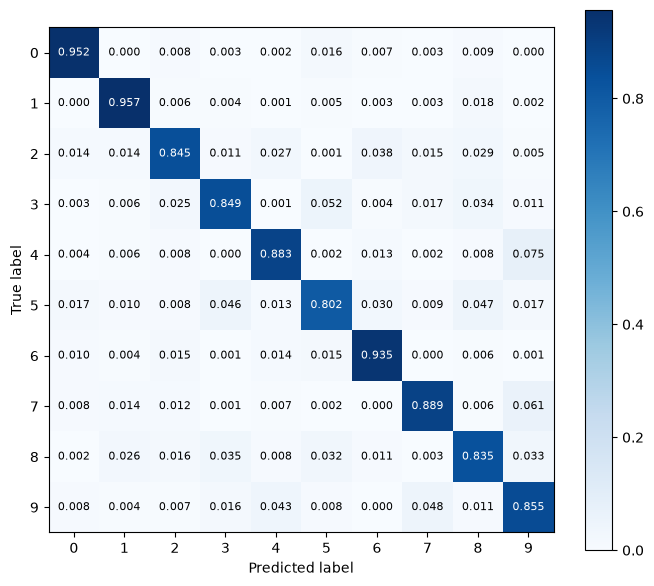

In [57]:
def plot_confusion_matrix(matrix, normalize=False, cmap="Blues"):
    values = matrix.detach().cpu().numpy().astype(np.float64)

    if normalize:
        row_totals = values.sum(axis=1, keepdims=True)
        display_values = np.divide(
            values,
            row_totals,
            out=np.zeros_like(values),
            where=row_totals != 0,
        )
        color_values = display_values
        value_format = ".3f"
    else:
        display_values = values
        color_values = np.log1p(values)
        value_format = ".0f"

    figure, axes = plt.subplots(figsize=(7, 6))
    image = axes.imshow(color_values, interpolation="nearest", cmap=cmap)
    figure.colorbar(image, ax=axes)

    classes = np.arange(10)
    axes.set(
        xticks=classes,
        yticks=classes,
        xlabel="Predicted label",
        ylabel="True label",
    )

    threshold = color_values.max() / 2.0
    for row in range(10):
        for column in range(10):
            axes.text(
                column,
                row,
                format(display_values[row, column], value_format),
                ha="center",
                va="center",
                color=(
                    "white"
                    if color_values[row, column] > threshold
                    else "black"
                ),
                fontsize=8,
            )

    figure.tight_layout()


plot_confusion_matrix(confusion_matrix, normalize=True)


Inspect the largest off-diagonal entries. Are the most common confusions visually plausible? A confusion matrix describes error patterns, but it does not by itself explain their cause. Inspect validation images before proposing explanations.

### Sensitivity to initial conditions

Training is stochastic. To isolate sensitivity to parameter initialization, every repeated run below uses:

- a different model seed;
- the same train/validation split;
- the same sequence of shuffled mini-batches.

This controls the data order rather than silently changing initialization and sampling together. The test set is deliberately excluded from this exploratory analysis.


In [58]:
dataset_loaders = {
    "train": DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=pin_memory,
    ),
    "validation": validation_loader,
}

losses = {name: [] for name in dataset_loaders}
accuracies = {name: [] for name in dataset_loaders}

for run in range(SENSITIVITY_RUNS):
    run_seed = MODEL_SEED + run
    print(
        f"Training model {run + 1}/{SENSITIVITY_RUNS} "
        f"with seed {run_seed}"
    )

    seed_everything(run_seed)
    repeated_model = make_mlp(dropout_probability=0.2).to(device)
    repeated_optimizer = torch.optim.SGD(
        repeated_model.parameters(), lr=0.01
    )
    repeated_train_loader = make_train_loader(DATA_ORDER_SEED)

    _ = fit(
        model=repeated_model,
        train_loader=repeated_train_loader,
        validation_loader=validation_loader,
        loss_function=loss_function,
        optimizer=repeated_optimizer,
        epochs=SENSITIVITY_EPOCHS,
        verbose=False,
    )

    for name, data_loader in dataset_loaders.items():
        metrics = evaluate(
            repeated_model, data_loader, loss_function
        )
        losses[name].append(metrics["loss"])
        accuracies[name].append(metrics["accuracy"])


Training model 1/3 with seed 4958
Training model 2/3 with seed 4959
Training model 3/3 with seed 4960


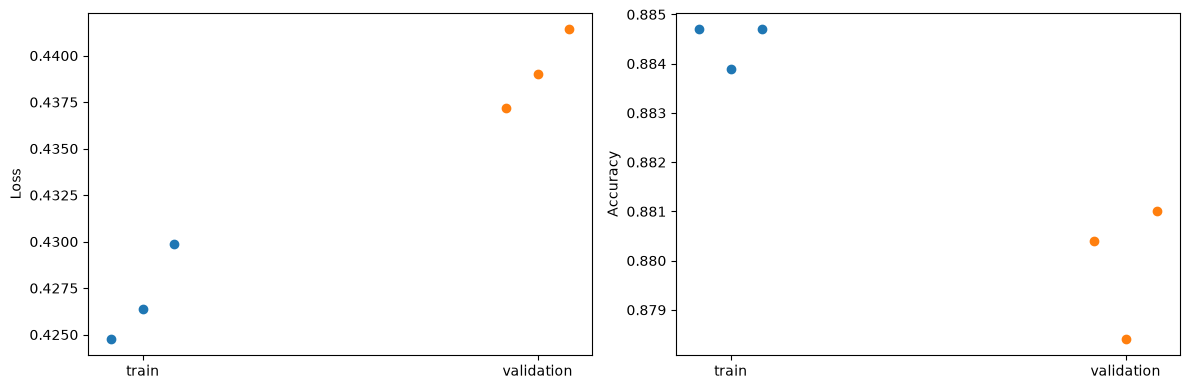

In [59]:
def plot_run_variation(losses, accuracies):
    names = list(losses)
    positions = np.arange(len(names))
    jitter = np.linspace(-0.08, 0.08, SENSITIVITY_RUNS)

    figure, axes = plt.subplots(1, 2, figsize=(12, 4))

    for position, name in zip(positions, names):
        axes[0].scatter(
            position + jitter, losses[name], label=name
        )
        axes[1].scatter(
            position + jitter, accuracies[name], label=name
        )

    for axis, ylabel in zip(axes, ["Loss", "Accuracy"]):
        axis.set_xticks(positions, names)
        axis.set_ylabel(ylabel)

    figure.tight_layout()


plot_run_variation(losses, accuracies)


In [60]:
for name in dataset_loaders:
    loss_values = np.asarray(losses[name])
    accuracy_values = np.asarray(accuracies[name])
    print(
        f"{name:10s}: "
        f"loss={loss_values.mean():.4f} ± {loss_values.std(ddof=0):.4f}, "
        f"accuracy={accuracy_values.mean():.4f} "
        f"± {accuracy_values.std(ddof=0):.4f}"
    )


train     : loss=0.4270 ± 0.0021, accuracy=0.8844 ± 0.0004
validation: loss=0.4392 ± 0.0018, accuracy=0.8799 ± 0.0011


## Interpretation questions

Answer these questions using only the training and validation evidence:

1. Does dropout reduce the training–validation gap? Does that necessarily mean it is the better model?
2. Which digit pairs have the largest off-diagonal validation confusion counts? Inspect several corresponding images before proposing an explanation.
3. Is variation across initialization seeds large enough to change your model-selection conclusion?
4. Would repeating the experiment with different train/validation splits answer the same scientific question? Why or why not?
5. Based on the declared validation-loss criterion, which model was selected? Would selecting by validation accuracy change the choice?
6. Which information—software versions, device, seeds, split, transformations, and hyperparameters—would someone need to reproduce the comparison?


## Final test evaluation

The model architecture and selection rule are now frozen. Evaluate the selected model on the test set exactly once to estimate its performance on unseen data.

Do not use this result to choose another model or tune another hyperparameter: doing so would turn the test set into another validation set. Further development requires returning to the validation workflow and reserving a fresh test or audit set for a new final evaluation.


In [61]:
selected_model_path = MODEL_DIR / "mnist_mlp_selected.pt"
torch.save(selected_model.state_dict(), selected_model_path)

final_test_metrics = evaluate(
    selected_model, test_loader, loss_function
)

print(f"Selected model: {selected_model_name}")
print(
    f"Final test: loss={final_test_metrics['loss']:.4f}, "
    f"accuracy={final_test_metrics['accuracy']:.4f}"
)
print(f"Saved selected weights to {selected_model_path}")


Selected model: classic
Final test: loss=0.4019, accuracy=0.8893
Saved selected weights to /home/gjb/Projects/Machine-learning-with-Python/source-code/pytorch/models/mnist_mlp_selected.pt
